1 Kurulum

In [ ]:
!pip -q install -U diffusers transformers accelerate peft safetensors torchvision


In [ ]:
import torch
print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
print("cuda version:", torch.version.cuda)


torch: 2.9.1+cu128
cuda available: True
cuda version: 12.8


2 Drive’ı bağla ve yolları tanımla

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

ROOT = "/content/drive/MyDrive/facecaption_local_poc_50k"
TRAIN_JSONL = f"{ROOT}/train.jsonl"
VAL_JSONL   = f"{ROOT}/val.jsonl"

# jsonl içinde image alanı "images/xxx.jpg" olduğu için root aynı klasör
IMG_ROOT = ROOT

OUT_DIR = "/content/drive/MyDrive/sd15_face_lora_50k"
import os
os.makedirs(OUT_DIR, exist_ok=True)

print("Train:", TRAIN_JSONL)
print("Val  :", VAL_JSONL)
print("Out  :", OUT_DIR)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Train: /content/drive/MyDrive/facecaption_local_poc_50k/train.jsonl
Val  : /content/drive/MyDrive/facecaption_local_poc_50k/val.jsonl
Out  : /content/drive/MyDrive/sd15_face_lora_50k


In [ ]:
import os

ROOT = "/content/drive/MyDrive/facecaption_local_poc_50k"

print("Root exists:", os.path.exists(ROOT))
print("Files in root:")
print(os.listdir(ROOT) if os.path.exists(ROOT) else "ROOT YOK")


Root exists: True
Files in root:
['images', 'train.jsonl', 'val.jsonl', 'manifest_local.jsonl']


3 Dataset + Dataloader (caption + image okuyacağız)

In [ ]:
import json, os
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

RESOLUTION = 512
BATCH_SIZE = 1

import random

class FaceCaptionDataset(Dataset):
    def __init__(self, jsonl_path, root_dir, resolution=512):
        with open(jsonl_path, "r", encoding="utf-8") as f:
            self.items = [json.loads(l) for l in f]
        self.root_dir = root_dir
        self.tfm = transforms.Compose([
            transforms.Resize((resolution, resolution)),
            transforms.ToTensor(),
            transforms.Normalize([0.5],[0.5])
        ])

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        for _ in range(3):  # bozuk image için 3 deneme
            try:
                it = self.items[idx]
                img_path = os.path.join(self.root_dir, it["image"])
                caption = it["caption"]

                img = Image.open(img_path).convert("RGB")
                img = self.tfm(img)

                return {"pixel_values": img, "caption": caption}

            except Exception:
                idx = random.randint(0, len(self.items) - 1)

        raise RuntimeError("Too many corrupted images")


train_ds = FaceCaptionDataset(TRAIN_JSONL, IMG_ROOT, RESOLUTION)
val_ds   = FaceCaptionDataset(VAL_JSONL,   IMG_ROOT, RESOLUTION)

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)

print("Train size:", len(train_ds))
print("Val size  :", len(val_ds))


Train size: 27275
Val size  : 3031


4 Sanity check (1 batch’i gör)

In [ ]:
batch = next(iter(train_dl))
print("Caption example:", batch["caption"][0][:120])
print("Image tensor shape:", batch["pixel_values"].shape)  # [B,3,512,512]


Caption example: The girl is young with bangs, black hair, no beard, pale skin, and straight hair.
Image tensor shape: torch.Size([1, 3, 512, 512])


5 Stable Diffusion v1.5 bileşenlerini yükleme

In [ ]:
from diffusers import StableDiffusionPipeline
import torch

MODEL_ID = "runwayml/stable-diffusion-v1-5"

pipe = StableDiffusionPipeline.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16,
    safety_checker=None,
    requires_safety_checker=False
)

pipe = pipe.to("cuda")

print("Stable Diffusion yüklendi ✅")


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/617 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/342 [00:00<?, ?B/s]

...

unet/diffusion_pytorch_model.safetensors:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!


Stable Diffusion yüklendi ✅


5.1 Pipeline içindeki parçaları tanıyalım (çok önemli)

In [ ]:
tokenizer     = pipe.tokenizer
text_encoder  = pipe.text_encoder
vae           = pipe.vae
unet          = pipe.unet

print("Tokenizer:", type(tokenizer))
print("Text encoder:", type(text_encoder))
print("VAE:", type(vae))
print("UNet:", type(unet))


Tokenizer: <class 'transformers.models.clip.tokenization_clip.CLIPTokenizer'>
Text encoder: <class 'transformers.models.clip.modeling_clip.CLIPTextModel'>
VAE: <class 'diffusers.models.autoencoders.autoencoder_kl.AutoencoderKL'>
UNet: <class 'diffusers.models.unets.unet_2d_condition.UNet2DConditionModel'>


5.2 Base model çalışıyor mu? (mini test)

  0%|          | 0/20 [00:00<?, ?it/s]

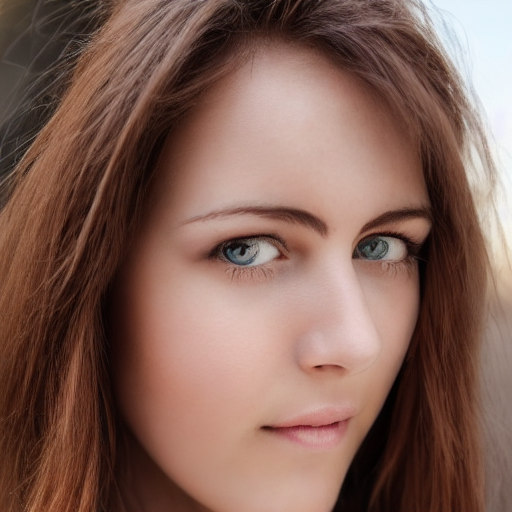

In [ ]:
prompt = "a frontal face photo of a young woman with brown hair, high quality"

with torch.autocast("cuda"):
    image = pipe(prompt, num_inference_steps=20, guidance_scale=7.5).images[0]

image


6 Base model test: Tek prompt ile yüz üret (sanity check)

  0%|          | 0/20 [00:00<?, ?it/s]

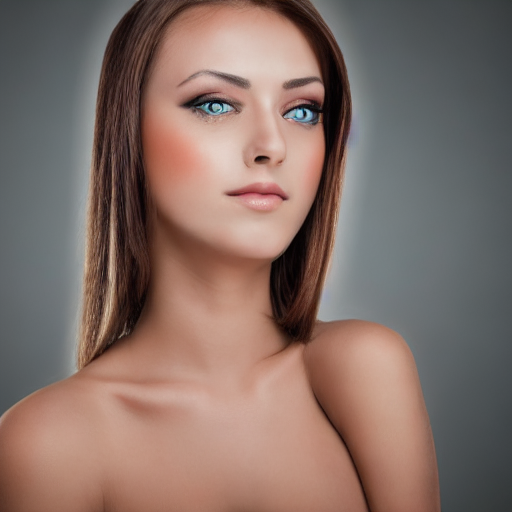

In [ ]:
prompt = "a frontal face photo of a young woman, high quality"

with torch.autocast("cuda"):
    img = pipe(prompt, num_inference_steps=20, guidance_scale=7.5).images[0]

img


7) Eğitim için parçaları ayır ve dondur

In [ ]:
tokenizer = pipe.tokenizer
text_encoder = pipe.text_encoder
vae = pipe.vae
unet = pipe.unet

vae.requires_grad_(False)
text_encoder.requires_grad_(False)
unet.requires_grad_(False)

print("✅ VAE + TextEncoder + UNet donduruldu (LoRA hariç)")


✅ VAE + TextEncoder + UNet donduruldu (LoRA hariç)


8) UNet’e LoRA ekle (attention katmanları)

In [ ]:
from peft import LoraConfig
import torch

# UNet'e adapter ekleyeceğiz
# target_modules: UNet attention içindeki linear katmanlar (SD1.5 için standart)
lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.0,
    bias="none",
    target_modules=["to_q", "to_k", "to_v", "to_out.0"],
)

unet.add_adapter(lora_config)
print("✅ LoRA adapter UNet'e eklendi")


✅ LoRA adapter UNet'e eklendi


9) Sadece LoRA parametrelerini eğitilebilir yap + say

In [ ]:
trainable = 0
total = 0

for name, p in unet.named_parameters():
    total += p.numel()
    if "lora" in name.lower():
        p.requires_grad = True
        trainable += p.numel()
    else:
        p.requires_grad = False

print("Total params:", f"{total:,}")
print("Trainable LoRA params:", f"{trainable:,}")


Total params: 861,115,332
Trainable LoRA params: 1,594,368


10) Eğitim için scheduler + optimizer hazırlığı

In [ ]:
import torch
import torch.nn.functional as F
from diffusers import DDPMScheduler

device = "cuda"

# Noise scheduler (diffusion)
noise_scheduler = DDPMScheduler.from_config(pipe.scheduler.config)

# Optimizer sadece trainable parametrelerle
trainable_params = [p for p in unet.parameters() if p.requires_grad]
optimizer = torch.optim.AdamW(trainable_params, lr=5e-5)  # hatta gerekirse 1e-5


print("✅ Scheduler + Optimizer hazır")
print("Trainable param tensors:", len(trainable_params))


✅ Scheduler + Optimizer hazır
Trainable param tensors: 256


11) Prompt encoding fonksiyonu (caption → CLIP embedding)

In [ ]:
def encode_prompts(prompts):
    tok = tokenizer(
        prompts,
        padding="max_length",
        truncation=True,
        max_length=tokenizer.model_max_length,
        return_tensors="pt"
    )
    input_ids = tok.input_ids.to(device)

    with torch.no_grad():
        enc = text_encoder(input_ids)[0]   # [B, seq, hidden]
    return enc

print("✅ encode_prompts hazır")


✅ encode_prompts hazır


12) 1 training step testi (loop’a girmeden önce)

Bu hücre “her şey çalışıyor mu?” diye tek batch’te loss hesaplar.

In [ ]:
unet.train()

batch = next(iter(train_dl))
pixel_values = batch["pixel_values"].to(device, dtype=torch.float16)
captions = list(batch["caption"])

# text embedding
encoder_hidden_states = encode_prompts(captions)

# image -> latent (VAE)
with torch.no_grad():
    latents = vae.encode(pixel_values).latent_dist.sample()
    latents = latents * 0.18215

# noise ekle
noise = torch.randn_like(latents)
timesteps = torch.randint(
    0, noise_scheduler.config.num_train_timesteps,
    (latents.shape[0],), device=device
).long()

noisy_latents = noise_scheduler.add_noise(latents, noise, timesteps)

# UNet noise prediction
with torch.autocast("cuda"):
    noise_pred = unet(noisy_latents, timesteps, encoder_hidden_states).sample
    loss = F.mse_loss(noise_pred.float(), noise.float(), reduction="mean")

print("✅ Loss:", loss.item())


✅ Loss: 0.1710560917854309


BÖLÜM 13 — Full Training Loop (LoRA eğitimi)

BÖLÜM 13 — Full Training Loop (LoRA eğitimi)

In [ ]:
from tqdm import tqdm

MAX_STEPS = 1500        # PoC için ideal (istersen 2000 yaparız)
GRAD_ACCUM = 4          # VRAM tasarrufu
SAVE_EVERY = 300        # kaç adımda bir LoRA kaydedilsin

global_step = 0
optimizer.zero_grad(set_to_none=True)

print("Training steps:", MAX_STEPS)


Training steps: 1500


13.2 Training loop

In [ ]:
# LoRA ağırlıklarını FP32 yap (stabil training için)
for name, p in unet.named_parameters():
    if "lora" in name.lower():
        p.data = p.data.float()
        if p.grad is not None:
            p.grad = p.grad.float()

print("✅ LoRA params casted to FP32")


✅ LoRA params casted to FP32


In [ ]:
import torch
import torch.nn.functional as F
from tqdm import tqdm

unet.train()
pbar = tqdm(total=MAX_STEPS, desc="LoRA Training")

accum_loss = 0.0
optimizer.zero_grad(set_to_none=True)

for epoch in range(9999):  # MAX_STEPS ile duracağız
    for batch in train_dl:
        pixel_values = batch["pixel_values"].to(device, dtype=torch.float16)
        captions = list(batch["caption"])

        # --- text → embedding ---
        encoder_hidden_states = encode_prompts(captions)

        # --- image → latent ---
        with torch.no_grad():
            latents = vae.encode(pixel_values).latent_dist.sample()
            latents = latents * 0.18215

        # ✅ latents bozuksa skip
        if not torch.isfinite(latents).all():
            print("⚠️ Bad latents, skipping batch")
            optimizer.zero_grad(set_to_none=True)
            continue

        # --- noise ekle ---
        noise = torch.randn_like(latents)
        timesteps = torch.randint(
            0, noise_scheduler.config.num_train_timesteps,
            (latents.shape[0],), device=device
        ).long()

        noisy_latents = noise_scheduler.add_noise(latents, noise, timesteps)

        # --- UNet forward ---
        with torch.autocast("cuda"):
            noise_pred = unet(noisy_latents, timesteps, encoder_hidden_states).sample
            loss = F.mse_loss(noise_pred.float(), noise.float(), reduction="mean")

        # ✅ NaN/Inf loss ise skip
        if not torch.isfinite(loss):
            print("⚠️ NaN loss detected, skipping batch")
            optimizer.zero_grad(set_to_none=True)
            continue

        # --- backward ---
        (loss / GRAD_ACCUM).backward()
        accum_loss += loss.item()

        # --- optimizer step ---
        if (global_step + 1) % GRAD_ACCUM == 0:
            # ✅ Gradient clipping
            torch.nn.utils.clip_grad_norm_(trainable_params, 1.0)

            optimizer.step()
            optimizer.zero_grad(set_to_none=True)

            pbar.update(1)
            pbar.set_postfix(loss=accum_loss / GRAD_ACCUM)
            accum_loss = 0.0

            # --- checkpoint ---
            if pbar.n % SAVE_EVERY == 0:
                ckpt = f"{OUT_DIR}/lora_step_{pbar.n}.pt"
                torch.save(unet.state_dict(), ckpt)
                print(f"\n💾 Checkpoint saved: {ckpt}")

            if pbar.n >= MAX_STEPS:
                break

        global_step += 1

    if pbar.n >= MAX_STEPS:
        break

pbar.close()
print("✅ Training finished")


LoRA Training:  20%|██        | 300/1500 [07:36<29:54,  1.50s/it, loss=0.231] 


💾 Checkpoint saved: /content/drive/MyDrive/sd15_face_lora_50k/lora_step_300.pt


LoRA Training:  21%|██        | 313/1500 [08:24<39:08,  1.98s/it, loss=0.0304]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
LoRA Training:  27%|██▋       | 404/1500 [10:45<28:13,  1.55s/it, loss=0.0454]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
LoRA Training:  40%|████      | 600/1500 [15:44<22:28,  1.50s/it, loss=0.349]


💾 Checkpoint saved: /content/drive/MyDrive/sd15_face_lora_50k/lora_step_600.pt


LoRA Training:  60%|██████    | 900/1500 [23:51<15:05,  1.51s/it, loss=0.0577]

...


💾 Checkpoint saved: /content/drive/MyDrive/sd15_face_lora_50k/lora_step_1200.pt


LoRA Training: 100%|██████████| 1500/1500 [41:31<00:00,  1.56s/it, loss=0.137]


💾 Checkpoint saved: /content/drive/MyDrive/sd15_face_lora_50k/lora_step_1500.pt


LoRA Training: 100%|██████████| 1500/1500 [42:06<00:00,  1.68s/it, loss=0.137]

✅ Training finished


BÖLÜM 14 — Eğitilen LoRA ile text → face üret (Inference)

14) Inference Fix: LoRA adapter ekle → checkpoint yükle → üret

In [ ]:
import torch
from diffusers import StableDiffusionPipeline
from peft import LoraConfig

MODEL_ID = "runwayml/stable-diffusion-v1-5"
CKPT = "/content/drive/MyDrive/sd15_face_lora_50k/lora_step_1500.pt"  # istersen 1200/900 da dene

pipe_inf = StableDiffusionPipeline.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16,
    safety_checker=None,
    requires_safety_checker=False
).to("cuda")

# ✅ Training'de kullandığınla aynı LoRA config
lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.0,
    bias="none",
    target_modules=["to_q", "to_k", "to_v", "to_out.0"],
)

# ✅ Önce adapter'ı tak
pipe_inf.unet.add_adapter(lora_config)

# ✅ Sonra LoRA'lı state_dict'i yükle
state = torch.load(CKPT, map_location="cuda")
pipe_inf.unet.load_state_dict(state, strict=True)

print("✅ LoRA checkpoint yüklendi:", CKPT)


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

✅ LoRA checkpoint yüklendi: /content/drive/MyDrive/sd15_face_lora_50k/lora_step_1500.pt


15) Text → Face üret ve Drive’a kaydet

  0%|          | 0/30 [00:00<?, ?it/s]

🖼️ Saved: /content/drive/MyDrive/sd15_face_lora_50k/gen_step1500_0.png
🖼️ Saved: /content/drive/MyDrive/sd15_face_lora_50k/gen_step1500_1.png


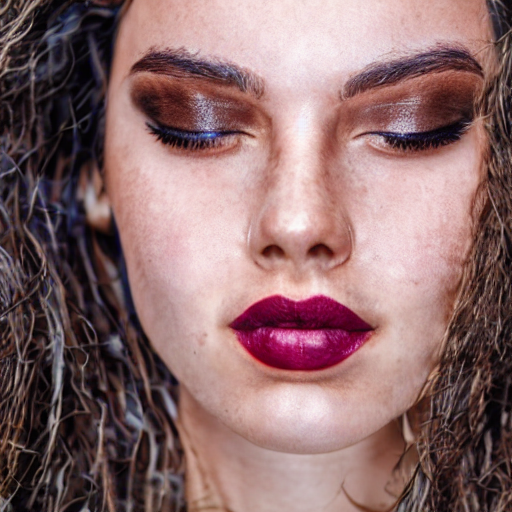

In [ ]:
import os

OUT_DIR = "/content/drive/MyDrive/sd15_face_lora_50k"
os.makedirs(OUT_DIR, exist_ok=True)

prompts = [
    "a frontal face photo of a young woman with brown hair and lipstick, realistic, high quality",
    "a frontal face photo of a young man with black hair, 5 o'clock shadow, pointy nose, realistic, high quality",
]

with torch.autocast("cuda"):
    images = pipe_inf(prompts, num_inference_steps=30, guidance_scale=7.0).images

for i, img in enumerate(images):
    path = f"{OUT_DIR}/gen_step1500_{i}.png"
    img.save(path)
    print("🖼️ Saved:", path)

images[0]
